<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/cvlab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Read the image in grayscale
img = cv2.imread("test.jpg", 0)

if img is None:
    print("Error: 'test.jpg' not found. Please upload it to the Colab files sidebar and refresh.")
else:
    print("Image loaded successfully!")

Image loaded successfully!


In [16]:
# Adding Gaussian Noise
noise = np.random.normal(0, 20, img.shape).astype(np.float32)
gaussian_noisy = img.astype(np.float32) + noise
gaussian_noisy = np.clip(gaussian_noisy, 0, 255).astype(np.uint8)

# Adding Salt-and-Pepper Noise
sp_noisy = img.copy()
num_pixels = 3000
# Adding Salt (white pixels)
x, y = np.random.randint(0, img.shape[0], num_pixels), np.random.randint(0, img.shape[1], num_pixels)
sp_noisy[x, y] = 255
# Adding Pepper (black pixels)
x, y = np.random.randint(0, img.shape[0], num_pixels), np.random.randint(0, img.shape[1], num_pixels)
sp_noisy[x, y] = 0

In [17]:
# Apply mean and Gaussian filters
mean_filtered = cv2.blur(gaussian_noisy, (5, 5))
gaussian_filtered = cv2.GaussianBlur(gaussian_noisy, (5, 5), 0)

# Apply median filter
median_filtered = cv2.medianBlur(sp_noisy, 5)

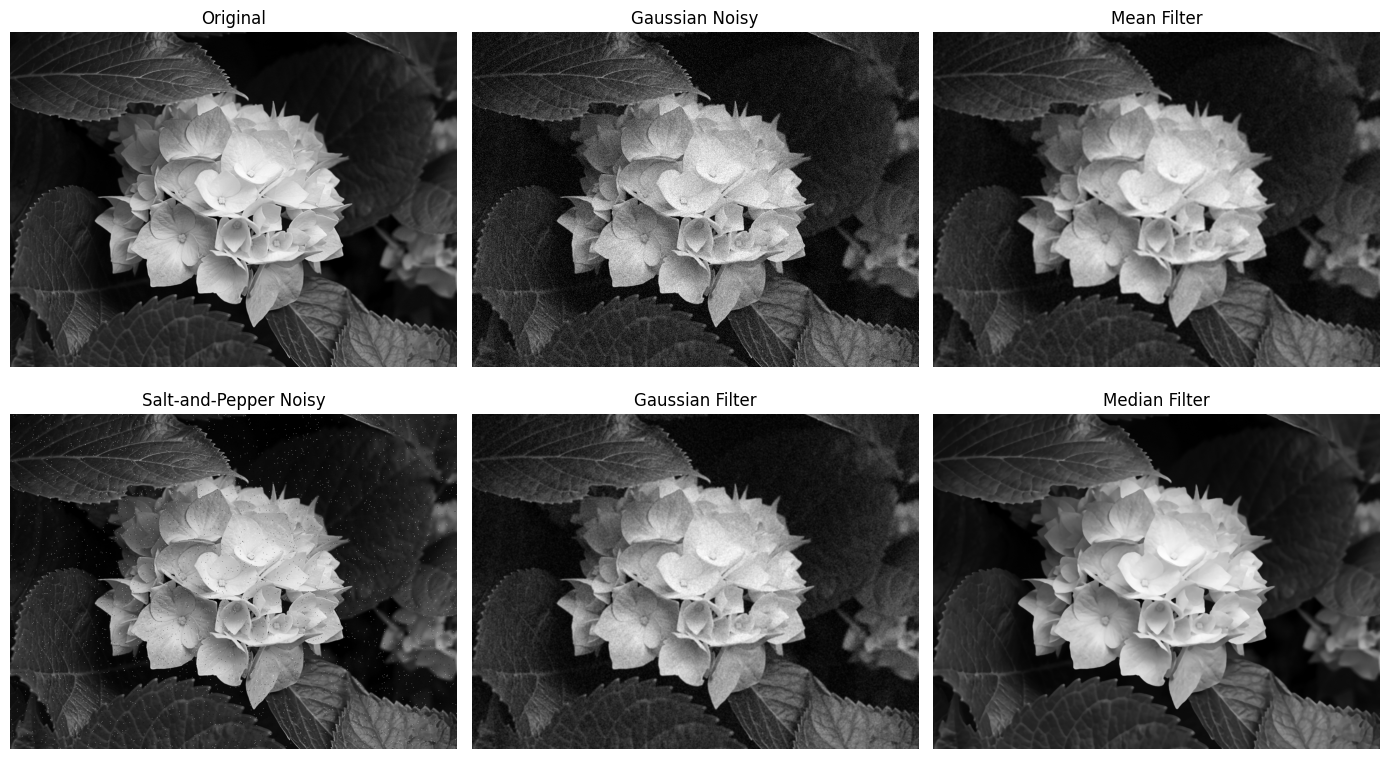

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax[0, 0].imshow(img, cmap="gray"); ax[0, 0].set_title("Original")
ax[0, 1].imshow(gaussian_noisy, cmap="gray"); ax[0, 1].set_title("Gaussian Noisy")
ax[0, 2].imshow(mean_filtered, cmap="gray"); ax[0, 2].set_title("Mean Filter")

ax[1, 0].imshow(sp_noisy, cmap="gray"); ax[1, 0].set_title("Salt-and-Pepper Noisy")
ax[1, 1].imshow(gaussian_filtered, cmap="gray"); ax[1, 1].set_title("Gaussian Filter")
ax[1, 2].imshow(median_filtered, cmap="gray"); ax[1, 2].set_title("Median Filter")

for a in ax.ravel(): a.axis("off")
plt.tight_layout()
plt.show()